# 金融数据挖掘图鉴：主代码复习版

对应源文件：`python_financial_coding.py`。

整理原则：按原代码顺序组织知识块；每个代码块把需要的库写在块内；联网数据和本地缺失文件用可复现的模拟数据替代，保留原始金融逻辑。

## 1. 现金流、年金、NPV 与 IRR

- 时间价值的核心是：不同时间点的现金流不能直接相加，必须折现或终值化。
- 年金是等间隔现金流；增长年金允许每期现金流按固定增长率 `g` 增长。
- NPV 用给定折现率评价项目是否创造价值；IRR 是令 NPV 等于 0 的内部收益率。
- 复习抓手：`NPV > 0` 通常表示项目收益率超过资本成本；`IRR` 可与要求收益率比较。

In [ ]:
import numpy_financial as npf

'''增长年金现值：把未来每一期增长现金流折现到今天。'''
def present_value_growing_annuity(first_cash_flow, discount_rate, growth_rate, periods):
    return first_cash_flow / (discount_rate - growth_rate) * (1 - ((1 + growth_rate) / (1 + discount_rate)) ** periods)

'''增长年金终值：把每一期现金流滚到最后一期。'''
def future_value_growing_annuity(first_cash_flow, discount_rate, growth_rate, periods):
    return first_cash_flow / (discount_rate - growth_rate) * ((1 + discount_rate) ** periods - (1 + growth_rate) ** periods)

'''延期永续年金：先算永续现金流在开始支付前一期的价值，再折现回今天。'''
def present_value_delayed_perpetuity(cash_flow, discount_rate, delay_years):
    return (cash_flow / discount_rate) / (1 + discount_rate) ** (delay_years - 1)

cash_flows = [-100, 50, 60, 70]
project_npv = npf.npv(0.05, cash_flows)
project_irr = npf.irr(cash_flows)
print(project_npv, project_irr)

## 2. 收益率计算、频率转换与分布观察

- 日收益率常用 `pct_change()`：衡量价格相邻两期的相对变化。
- 多期收益率不能简单相加，简单收益率应先转成 `1 + r` 后连乘；对数收益率可以按时间加总。
- 收益率分布图可以帮助识别偏度、厚尾和异常波动；红色正态曲线常作为“基准参照”，不是说真实收益一定正态。

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(123)
dates = pd.bdate_range('2023-01-01', periods=500)
prices = pd.Series(100 * np.exp(np.cumsum(np.random.normal(0.0005, 0.015, len(dates)))), index=dates, name='Close')

'''日收益率：金融数据挖掘最常用的基础变量。'''
daily_returns = prices.pct_change().dropna()

'''年度收益率：把每天的 1+r 连乘，再减 1。'''
annual_returns = (1 + daily_returns).groupby(daily_returns.index.year).prod() - 1

'''月度收益率：同理，先构造 YYYYMM 再分组连乘。'''
year_month = daily_returns.index.year * 100 + daily_returns.index.month
monthly_returns = (1 + daily_returns).groupby(year_month).prod() - 1

t_test_result = stats.ttest_1samp(daily_returns, 0)
print(annual_returns.head())
print(t_test_result)

plt.hist(daily_returns, bins=45, density=True, alpha=0.65)
x = np.linspace(daily_returns.min(), daily_returns.max(), 200)
plt.plot(x, stats.norm.pdf(x, daily_returns.mean(), daily_returns.std()), color='red')
plt.title('Daily Return Distribution')
plt.show()

**结果复现：收益率分布**

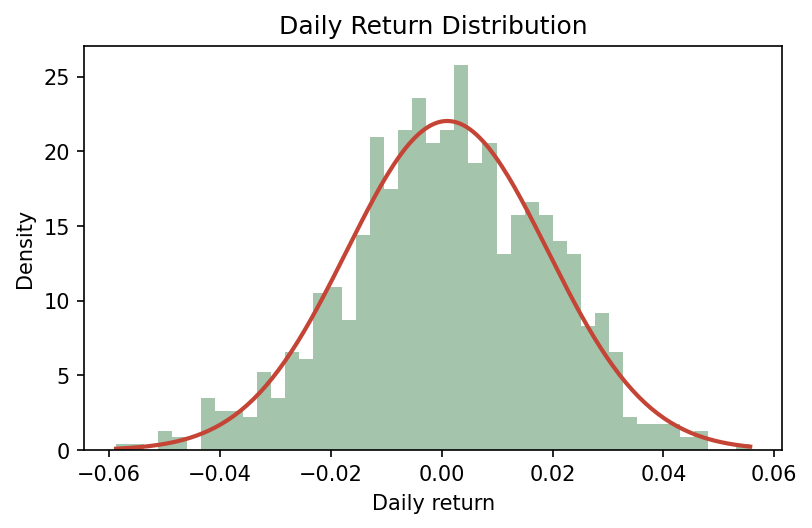

- 模拟日收益率均值约为 `0.00098`，标准差约为 `0.01810`。
- 直方图展示经验分布，红线展示同均值和标准差下的正态密度。
- 复习时要记住：金融收益率经常出现厚尾，所以正态曲线更多是比较基准，而不是严格事实。

## 3. Fama-French 因子、t 检验与单样本/双样本思想

- Fama-French 三因子把资产超额收益拆成市场、规模、价值三个风险暴露。
- 单样本 t 检验常问：某个平均收益是否等于 0。
- 双样本 t 检验常问：两只股票或两组策略的平均收益是否不同。
- `p_value < 0.05` 通常表示在 5% 显著性水平下拒绝原假设。

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm

np.random.seed(7)
sample_size = 252
stock_a_returns = np.random.normal(0.0007, 0.018, sample_size)
stock_b_returns = np.random.normal(0.0003, 0.016, sample_size)

'''比较两组日收益均值是否显著不同。'''
two_sample_test = stats.ttest_ind(stock_a_returns, stock_b_returns, equal_var=False)
print(two_sample_test)

factor_data = pd.DataFrame({
    'MKT_RF': np.random.normal(0.0005, 0.01, sample_size),
    'SMB': np.random.normal(0.0001, 0.006, sample_size),
    'HML': np.random.normal(0.0001, 0.007, sample_size),
    'RF': 0.00008,
})
asset_return = 0.0002 + 1.1 * factor_data['MKT_RF'] + 0.25 * factor_data['SMB'] - 0.15 * factor_data['HML'] + np.random.normal(0, 0.008, sample_size)

'''Fama-French 回归：解释资产超额收益来自哪些风险因子。'''
y = asset_return - factor_data['RF']
x = sm.add_constant(factor_data[['MKT_RF', 'SMB', 'HML']])
ff3_model = sm.OLS(y, x).fit()
print(ff3_model.summary())

## 4. 债券估值、利率期限结构与久期

- 债券价格是未来票息和本金的折现值。
- 到期收益率 YTM 是让债券现金流现值等于市场价格的折现率。
- Macaulay Duration 是现金流收回时间的加权平均，权重来自每笔现金流现值占债券价格的比例。
- 修正久期近似衡量利率变化对债券价格的敏感度：利率上升，债券价格下降。

In [ ]:
import numpy_financial as npf
import matplotlib.pyplot as plt

def bond_price(face_value, coupon_rate, ytm, years, frequency):
    '''债券价格 = 票息现值 + 本金现值。'''
    coupon_payment = face_value * coupon_rate / frequency
    return -npf.pv(ytm / frequency, years * frequency, coupon_payment, face_value)

def macaulay_duration(face_value, coupon_rate, ytm, years, frequency):
    '''每期现金流按现值占比加权，得到平均收回期限。'''
    periods = years * frequency
    price = bond_price(face_value, coupon_rate, ytm, years, frequency)
    duration = 0
    for period in range(1, periods + 1):
        time = period / frequency
        cash_flow = face_value * coupon_rate / frequency
        if period == periods:
            cash_flow += face_value
        present_value = cash_flow / (1 + ytm / frequency) ** period
        duration += (present_value / price) * time
    return duration

price = bond_price(1000, 0.07, 0.05, 10, 2)
duration = macaulay_duration(1000, 0.07, 0.05, 10, 2)
print(price, duration)

**结果复现：期限结构与久期**

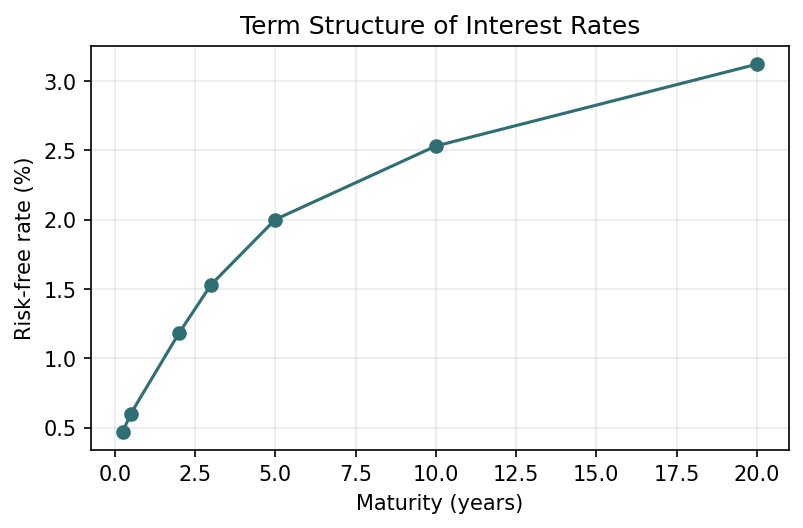

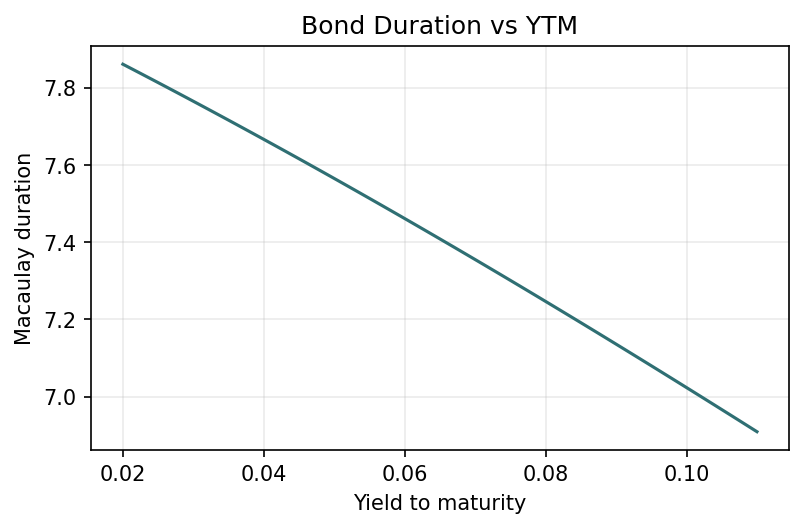

- 期限结构图把不同期限的无风险利率连起来，是理解债券定价和宏观预期的入口。
- 久期图中，YTM 越高，较远现金流的现值权重通常下降，Macaulay 久期也会下降。

## 5. CAPM、线性回归与 Beta

- CAPM 写作 `R_i - R_f = alpha + beta * (R_m - R_f) + error`。
- Beta 是股票对市场组合的系统性风险暴露，在单因子回归里就是斜率。
- Alpha 是模型不能解释的平均超额收益；显著不为 0 时，才可能讨论异常收益。
- `R-squared` 表示市场因子解释了多少股票收益波动。

In [ ]:
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

stock_returns = [0.065, 0.0265, -0.0593, -0.001, 0.0345]
market_returns = [0.055, -0.09, -0.041, 0.045, 0.022]

'''方法 1：scipy 直接给出斜率 beta、截距 alpha 和相关性。'''
beta, alpha, r_value, p_value, std_err = stats.linregress(market_returns, stock_returns)
print(beta, alpha, r_value, p_value)

'''方法 2：statsmodels OLS，更适合查看完整回归表。'''
x = sm.add_constant(market_returns)
capm_result = sm.OLS(stock_returns, x).fit()
print(capm_result.summary())

**结果复现：CAPM 回归图**

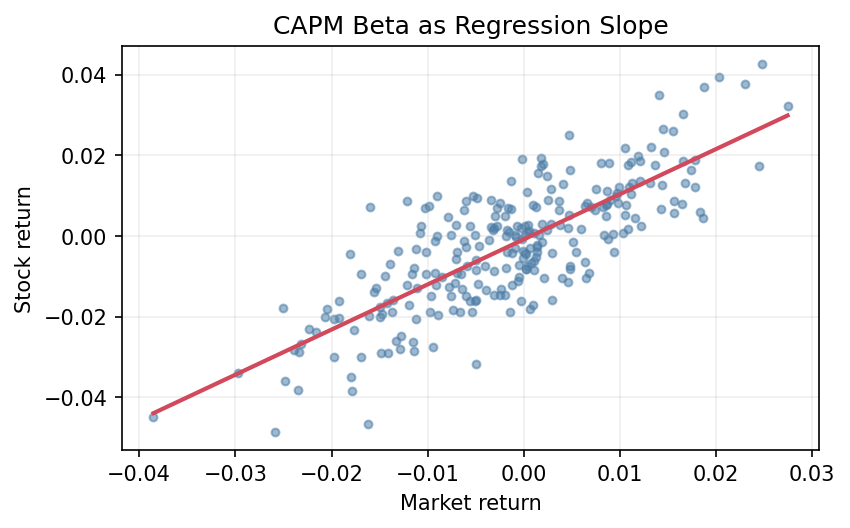

- 模拟数据估计出的 beta 约为 `1.120`，说明股票收益对市场收益的敏感度高于 1。
- 相关系数约为 `0.792`，p 值约为 `0.0000`，可用于判断市场因子是否显著。

## 6. 假设检验：正态、F 分布、方差齐性与均值差异

- 正态分布的 `cdf` 给累计概率，`ppf` 给分位点，常用于置信区间和 z 检验。
- F 检验常用于比较两个总体方差是否相等。
- Levene 检验比传统 F 检验更稳健，金融收益率不完全正态时尤其常用。
- 均值检验前先考虑方差是否相等，会影响双样本 t 检验的参数选择。

In [ ]:
import numpy as np
import scipy.stats as stats

np.random.seed(2026)
group_1 = np.random.normal(0.02, 0.10, 80)
group_2 = np.random.normal(0.04, 0.14, 80)

'''F 统计量：较大样本方差 / 较小样本方差。'''
variance_ratio = max(group_1.var(ddof=1), group_2.var(ddof=1)) / min(group_1.var(ddof=1), group_2.var(ddof=1))
f_critical = stats.f.ppf(0.95, len(group_1) - 1, len(group_2) - 1)
print(variance_ratio, f_critical)

'''Levene 检验：原假设是两组方差相等。'''
print(stats.levene(group_1, group_2))

'''Welch t-test：不强制假设两组方差相等。'''
print(stats.ttest_ind(group_1, group_2, equal_var=False))

**结果复现：置信区间与 F 分布**

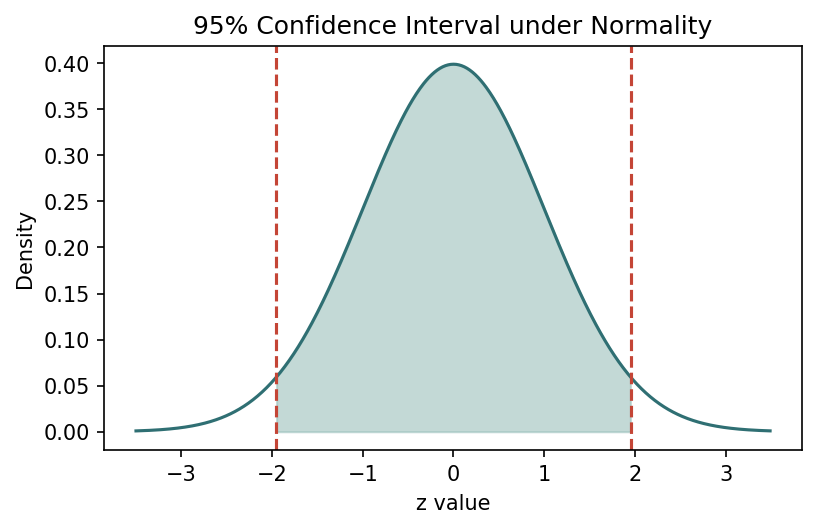

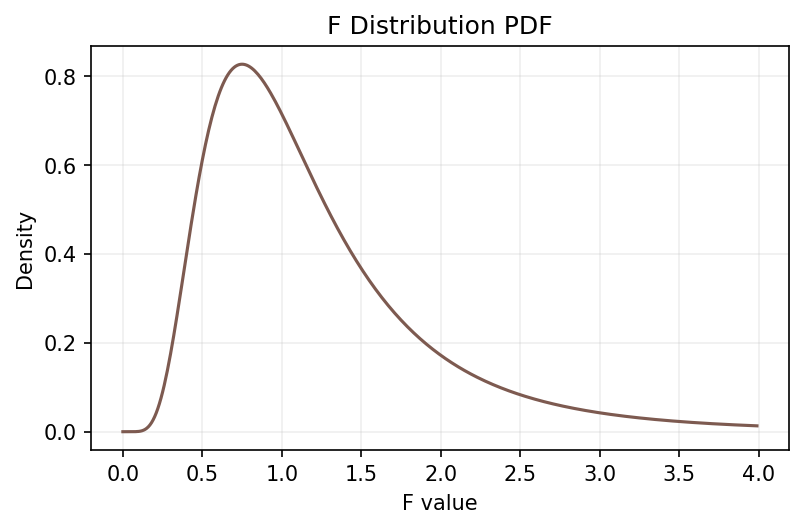

- 95% 置信区间对应中间 95% 的概率面积，两侧各留下 2.5%。
- F 分布右偏且非负，用于方差比；如果统计量落入右尾极端区域，就倾向于拒绝方差相等。

## 7. 时间序列：滞后、插值、Granger 因果与一月效应

- 时间序列检验关注“顺序”：今天的数据可能受昨天或更早的信息影响。
- Durbin-Watson 用于检查回归残差的一阶自相关，约等于 2 表示无明显自相关。
- Granger 因果不是哲学因果，而是预测意义：加入 X 的滞后项后，是否能更好预测 Y。
- 一月效应是市场异象检验：比较一月收益和非一月收益是否显著不同。

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm

np.random.seed(99)
n = 120
chicken = np.random.normal(size=n).cumsum()
egg = 0.4 * np.roll(chicken, 1) + np.random.normal(size=n)
series = pd.DataFrame({'chicken': chicken, 'egg': egg}).iloc[3:].copy()

for lag in [1, 2, 3]:
    series[f'chicken_lag{lag}'] = series['chicken'].shift(lag)
    series[f'egg_lag{lag}'] = series['egg'].shift(lag)
series = series.dropna()

'''受限模型：只用 egg 自己的滞后解释 egg。'''
restricted_x = sm.add_constant(series[['egg_lag1', 'egg_lag2', 'egg_lag3']])
restricted_model = sm.OLS(series['egg'], restricted_x).fit()

'''非受限模型：加入 chicken 的滞后项，看解释力是否提升。'''
full_x = sm.add_constant(series[['egg_lag1', 'egg_lag2', 'egg_lag3', 'chicken_lag1', 'chicken_lag2', 'chicken_lag3']])
full_model = sm.OLS(series['egg'], full_x).fit()
print(restricted_model.rsquared, full_model.rsquared)

## 8. 投资组合理论与优化

- 组合方差不只是单个资产方差的加权平均，还包含协方差项。
- 相关系数越低，分散化效果越强；这就是“不要只看单资产收益”的原因。
- 均值-方差优化常见目标是最大化 Sharpe Ratio。
- 约束条件通常包括权重和为 1、不能卖空、行业暴露限制等。

In [ ]:
import numpy as np
from scipy.optimize import minimize

expected_returns = np.array([0.08, 0.11, 0.06])
covariance_matrix = np.array([[0.040, 0.018, 0.010], [0.018, 0.060, 0.016], [0.010, 0.016, 0.025]])
risk_free_rate = 0.02

def negative_sharpe_ratio(weights):
    '''优化器默认做最小化，所以最大化 Sharpe 等价于最小化负 Sharpe。'''
    portfolio_return = weights @ expected_returns
    portfolio_volatility = np.sqrt(weights @ covariance_matrix @ weights)
    return -(portfolio_return - risk_free_rate) / portfolio_volatility

constraints = ({'type': 'eq', 'fun': lambda weights: weights.sum() - 1})
bounds = [(0, 1), (0, 1), (0, 1)]
initial_weights = np.array([1/3, 1/3, 1/3])
result = minimize(negative_sharpe_ratio, initial_weights, bounds=bounds, constraints=constraints)
print(result.x, -result.fun)

**结果复现：组合风险收益图**

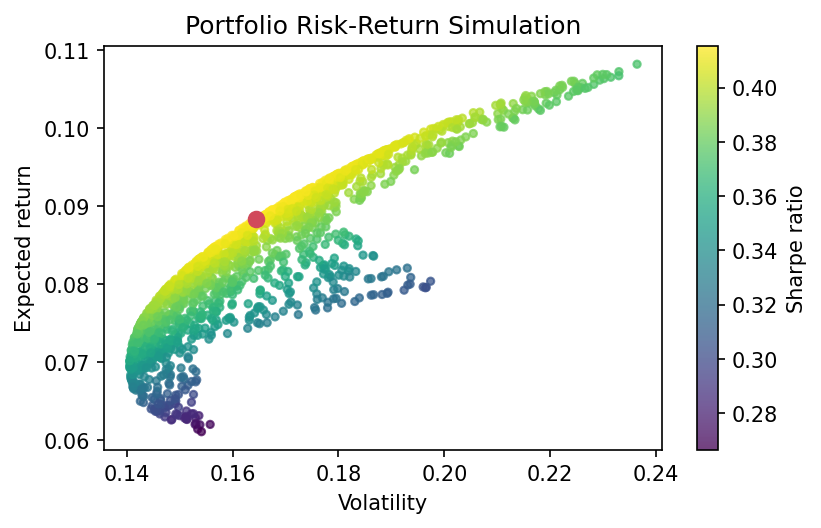

- 图中每个点是一组随机权重组合，颜色越亮 Sharpe Ratio 越高。
- 模拟下较优权重约为 `[0.356, 0.424, 0.221]`，Sharpe Ratio 约为 `0.415`。

## 9. 期权、Black-Scholes、隐含波动率与 Greeks

- 看涨期权 payoff 是 `max(S_T - K, 0)`，利润还要减去期权费。
- BSM 模型在风险中性世界下给欧式期权定价。
- 隐含波动率是把市场期权价格反推回 BSM 模型得到的 `sigma`。
- Delta 衡量期权价格对标的价格的一阶敏感度；Gamma 衡量 Delta 对标的价格的敏感度。

In [ ]:
from math import exp, log, sqrt
import numpy as np
import scipy.stats as stats

def black_scholes_call(stock_price, strike_price, time_to_maturity, risk_free_rate, volatility):
    '''BSM 看涨期权价格。'''
    d1 = (log(stock_price / strike_price) + (risk_free_rate + volatility ** 2 / 2) * time_to_maturity) / (volatility * sqrt(time_to_maturity))
    d2 = d1 - volatility * sqrt(time_to_maturity)
    return stock_price * stats.norm.cdf(d1) - strike_price * exp(-risk_free_rate * time_to_maturity) * stats.norm.cdf(d2)

def implied_volatility_call(stock_price, strike_price, time_to_maturity, risk_free_rate, market_call_price):
    '''网格搜索：找出使模型价格最接近市场价格的波动率。'''
    best_volatility = None
    smallest_error = float('inf')
    for i in range(1, 10000):
        volatility = 0.0001 * i
        model_price = black_scholes_call(stock_price, strike_price, time_to_maturity, risk_free_rate, volatility)
        error = abs(model_price - market_call_price)
        if error < smallest_error:
            smallest_error = error
            best_volatility = volatility
    return best_volatility

print(black_scholes_call(10, 10, 0.5, 0.01, 0.2))
print(implied_volatility_call(10, 10, 0.5, 0.01, 2))

**结果复现：期权收益与波动率微笑**

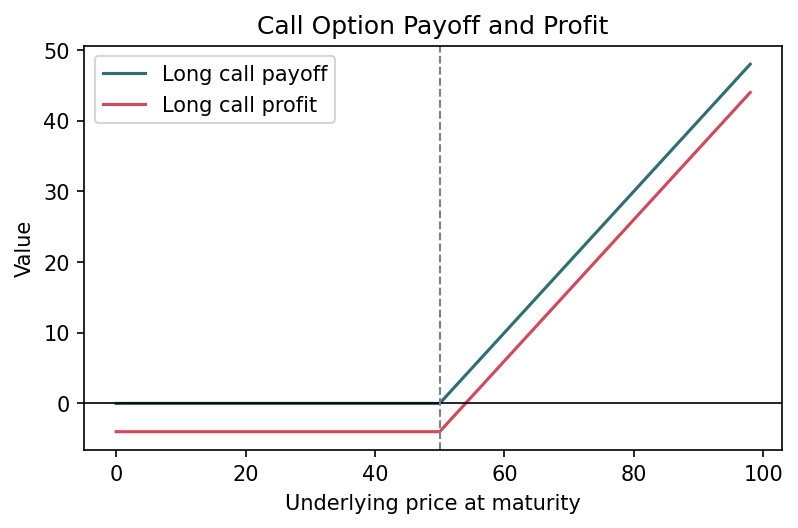

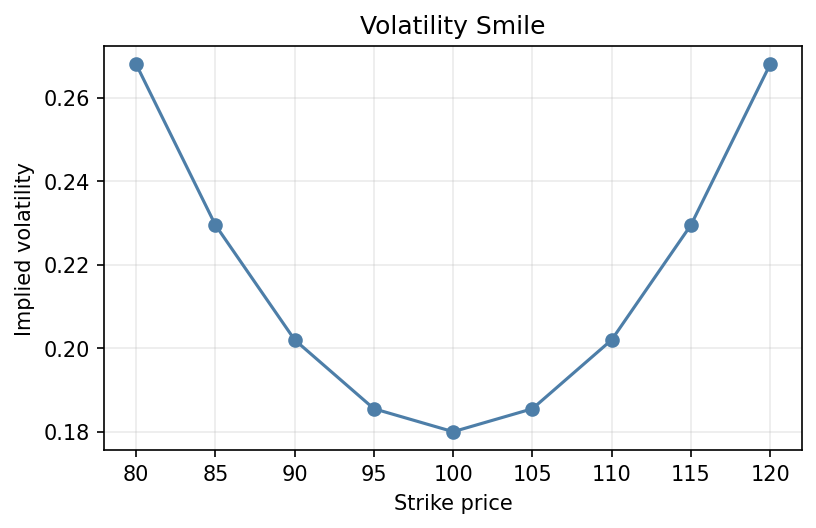

- 看涨期权在标的价格低于行权价时 payoff 为 0，但利润仍亏掉期权费。
- 波动率微笑说明市场并不认为所有行权价共享同一个波动率，这也是 BSM 常数波动率假设的现实偏离。

## 10. SQL 与 DataFrame Join

- `INNER JOIN` 只保留两边都匹配的记录。
- `LEFT JOIN` 保留左表全部记录，右表没有匹配则补缺失值。
- 在金融数据里，按日期合并行情、因子、宏观变量时，join 类型会直接影响样本量和缺失值。

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

cursor.execute('CREATE TABLE departments (dept_id INTEGER PRIMARY KEY, dept_name TEXT)')
cursor.execute('CREATE TABLE employees (id INTEGER PRIMARY KEY, name TEXT, dept_id INTEGER)')
cursor.executemany('INSERT INTO departments VALUES (?, ?)', [(10, 'ENG'), (20, 'HR'), (30, 'MKT')])
cursor.executemany('INSERT INTO employees VALUES (?, ?, ?)', [(1, 'Alice', 10), (2, 'Bob', 20), (3, 'Charlie', None)])

'''LEFT JOIN 会保留 Charlie，即使他没有对应部门。'''
left_join_query = '''
SELECT employees.name, departments.dept_name
FROM employees
LEFT JOIN departments ON employees.dept_id = departments.dept_id
'''
joined_data = pd.read_sql_query(left_join_query, conn)
conn.close()
print(joined_data)